Pearson Correlation Coefficient with Target:
Screen Time (hrs/day)           0.036491
Sleep Duration (hrs)            0.023520
Physical Activity (hrs/week)   -0.008395
Stress Level Enc               -0.030854
Anxious Enc                    -0.004377
Name: Target Enc, dtype: float64

Information Gain (Mutual Information) with Target:
Screen Time (hrs/day)           0.000000
Sleep Duration (hrs)            0.000000
Physical Activity (hrs/week)    0.032263
Stress Level Enc                0.000801
Anxious Enc                     0.000125
dtype: float64


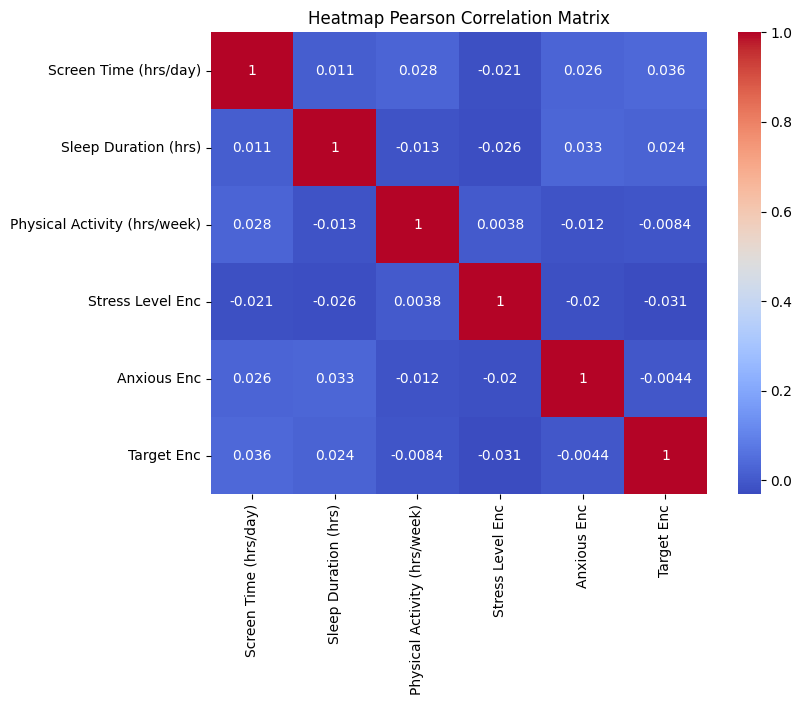


Most relevant feature by Pearson Correlation: Screen Time (hrs/day)
Most relevant feature by Information Gain: Physical Activity (hrs/week)


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('Student Mental Health Analysis During Online Learning.csv')

# Encode categorical variables
le_stress = LabelEncoder()
df['Stress Level Enc'] = le_stress.fit_transform(df['Stress Level'])

le_anxious = LabelEncoder()
df['Anxious Enc'] = le_anxious.fit_transform(df['Anxious Before Exams'])

le_target = LabelEncoder()
df['Target Enc'] = le_target.fit_transform(df['Academic Performance Change'])

# Select features and target
features = ['Screen Time (hrs/day)', 'Sleep Duration (hrs)', 'Physical Activity (hrs/week)', 'Stress Level Enc', 'Anxious Enc']
target = 'Target Enc'

# Calculate Pearson Correlation matrix
corr_matrix = df[features + [target]].corr()

print("Pearson Correlation Coefficient with Target:")
print(corr_matrix[target].drop(target))

# Calculate Information Gain (Mutual Information)
X = df[features]
y = df[target]

# Specify which features are discrete (encoded categorical)
discrete_features = [False, False, False, True, True]

mi = mutual_info_classif(X, y, discrete_features=discrete_features, random_state=42)
ig = pd.Series(mi, index=features)

print("\nInformation Gain (Mutual Information) with Target:")
print(ig)

# Visualize correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Heatmap Pearson Correlation Matrix')
plt.show()

# Determine most relevant feature by each method
max_corr_feature = corr_matrix[target].drop(target).abs().idxmax()
max_ig_feature = ig.idxmax()

print(f"\nMost relevant feature by Pearson Correlation: {max_corr_feature}")
print(f"Most relevant feature by Information Gain: {max_ig_feature}")
